In [1]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import pandas as pd
from utils import simulate_bagging_and_variance, save_results_png, save_result_csv
import pandas as pd
import os

In [2]:
####### Simulation parameters  #####################
portion_non_zero_weights = 0.45
n_sim = 1_00
B = 2_00
args = {"max_leaf_nodes": 5}
seed = 42

n = int(500/portion_non_zero_weights)
m = int(n * portion_non_zero_weights)

####### sim description ############################
text = f"ohne independency correction \nmit emp std für Konfidenzintervall\nmit weighted Bootstrap\nmit {portion_non_zero_weights*100}% non-zero weights\n"
folder_name = f"figure2_wager_weighted_{portion_non_zero_weights}_"

folder_name2 = folder_name + "_nx" + str(m)
if not os.path.exists("./figures/" + folder_name2):
    os.makedirs("./figures/" + folder_name2)
with open("./figures/" + folder_name2 + "/readme.txt", "w") as f:
    f.write(text)

Simulations: 100%|██████████| 100/100 [00:05<00:00, 19.17simulation/s]
c:\Users\rehan\meine_Repos\Masterarbeit\02_figure2_wager\utils.py:56: RuntimeWarning: invalid value encountered in sqrt
  unbiased_std_estimate = (est_vars_biased - bias_correction) ** 0.5


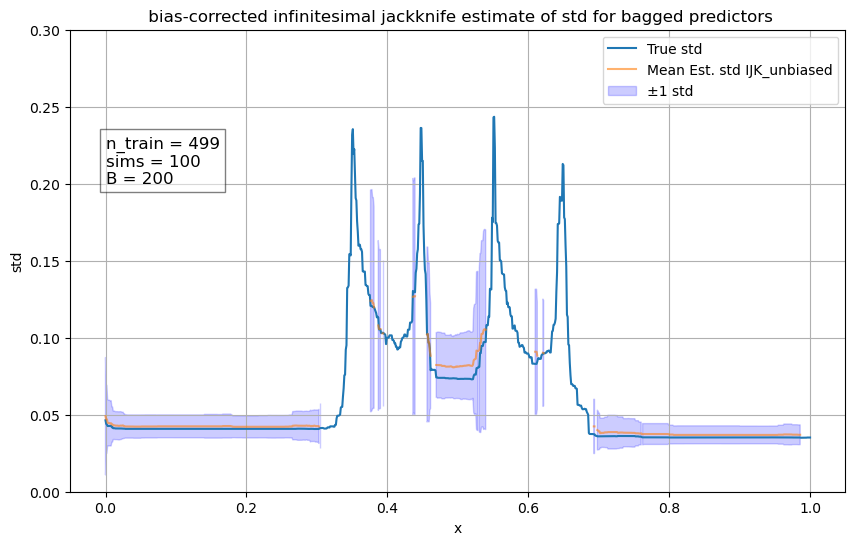

In [3]:
fix_x_points = True

# data and weights for X
x_fix = np.linspace(0, 1, n)
new_data = np.linspace(0, 1, 2 * m)

rng = np.random.default_rng(seed)
weights = np.zeros(n)
weights += 1 / m
index_drop = rng.choice(range(n), size=n - m, replace=False)
weights[index_drop] = 0.0

# variables to store results
bagged_preds = np.zeros((n_sim, new_data.shape[0]))
biased_var_estimates = np.zeros((n_sim, new_data.shape[0]))
bias_corrections = np.zeros((n_sim, new_data.shape[0]))

# run simulations
with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(
            simulate_bagging_and_variance,
            x1=x_fix,
            B=B,
            new_data=new_data,
            simulation_index=i,
            seed=seed,
            dt_args=args,
            weights=weights,
            m=m,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        bagged_prediction, biased_var_estimate, bias_correction = future.result()
        bagged_preds[i, :] = bagged_prediction
        biased_var_estimates[i, :] = biased_var_estimate
        bias_corrections[i, :] = bias_correction

# save results
save_result_csv(
    seed=seed,
    B=B,
    args=args,
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    new_data=new_data,
    folder_name=folder_name + f"_nx{m}",
    fix_x_points=fix_x_points,
)

save_results_png(
    new_data=new_data,
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    folder_name=folder_name + f"_nx{m}",
    n_data_points=n,
    B=B,
    seed=seed,
    dt_args=args,
    fixed_x_points=fix_x_points,
    m=m,
)

Simulations: 100%|██████████| 100/100 [00:05<00:00, 18.72simulation/s]
c:\Users\rehan\meine_Repos\Masterarbeit\02_figure2_wager\utils.py:56: RuntimeWarning: invalid value encountered in sqrt
  unbiased_std_estimate = (est_vars_biased - bias_correction) ** 0.5


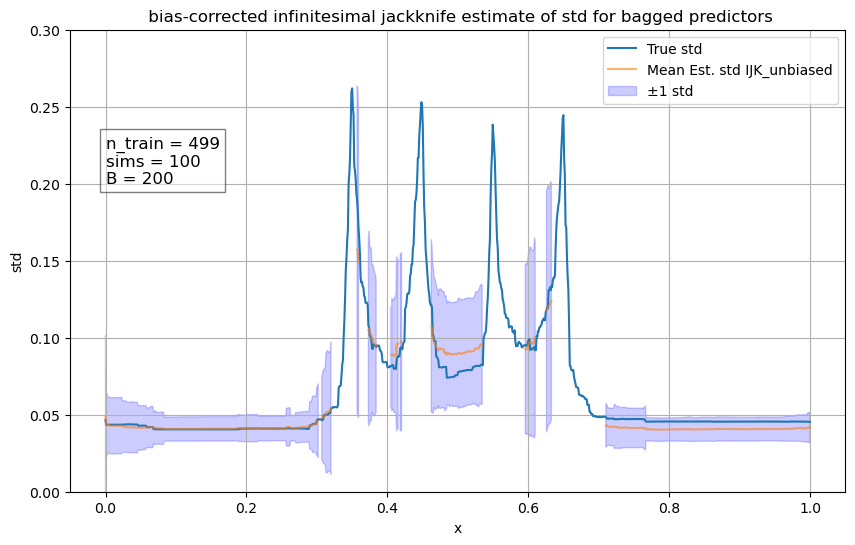

In [5]:
fix_x_points = False

# data for X
x_new = np.zeros((n_sim, n))
rng = np.random.default_rng(seed)
for x in range(n_sim):
    x_new[x] = rng.uniform(0, 1, n)
new_data = np.linspace(0, 1, 2 * m)

# weights for X
weights = np.zeros((n_sim, n))
weights += 1 / m
for i in range(n_sim):
    rng = np.random.default_rng(seed+i)
    index_drop = rng.choice(range(n), size=(n - m), replace=False)
    weights[i, index_drop] = 0.0

# variables to store results
bagged_preds = np.zeros((n_sim, new_data.shape[0]))
biased_var_estimates = np.zeros((n_sim, new_data.shape[0]))
bias_corrections = np.zeros((n_sim, new_data.shape[0]))

# run simulations
with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(
            simulate_bagging_and_variance,
            x1=x_new[i],
            B=B,
            new_data=new_data,
            simulation_index=i,
            seed=seed,
            dt_args=args,
            weights=weights[i],
            m=m,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        bagged_prediction, biased_var_estimate, bias_correction = future.result()
        bagged_preds[i, :] = bagged_prediction
        biased_var_estimates[i, :] = biased_var_estimate
        bias_corrections[i, :] = bias_correction

# save results
save_result_csv(
    seed=seed,
    B=B,
    args=args,
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    new_data=new_data,
    folder_name=folder_name + f"_nx{n}",
    fix_x_points=fix_x_points,
)

save_results_png(
    new_data=new_data,
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    folder_name=folder_name + f"_nx{m}",
    n_data_points=n,
    B=B,
    seed=seed,
    dt_args=args,
    fixed_x_points=fix_x_points,
    m=m
)